# 03 - Treinamento e Avaliação de Modelos

**Objetivo:** Este notebook utiliza o conhecimento da análise exploratória para treinar, avaliar e comparar diferentes modelos de Machine Learning, com o objetivo de encontrar o classificador mais preciso e robusto para o nosso problema.

**Etapas:**
1.  **Configuração e Preparação dos Dados**: Carrega os dados e aplica a engenharia de features desenvolvida no notebook anterior.
2.  **Divisão de Dados**: Separa os dados em conjuntos de treino e teste para uma avaliação imparcial.
3.  **Seleção de Features**: Define um subconjunto de features para treinar um modelo mais simples e eficiente.
4.  **Divisão de Dados**: Separa os dados em conjuntos de treino e teste para uma avaliação imparcial.
5.  **Modelo de Base (Gaussian Naive Bayes)**: Treina e avalia o modelo atual para estabelecer uma linha de base de performance.
6.  **Experimentação com Modelos Avançados**: Treina e avalia `Random Forest` e `LightGBM` para buscar uma performance superior.
7.  **Comparação e Seleção**: Compara a performance de todos os modelos usando validação cruzada para escolher o melhor.
8.  **Análise de Importância das Features**: Investiga quais features mais contribuíram para a decisão do melhor modelo.
9.  **Treinamento e Exportação do Modelo Final**: Treina o modelo `GaussianNB` com todos os dados e o exporta no formato correto para uso no dashboard.

In [15]:
# =============================================================================
# Celula 0: Fonte de dados (CSV FEATURES)
# =============================================================================
import os
import sys
import json
from datetime import datetime
from pathlib import Path
import pandas as pd

# --- Bootstrap para importar modulos compartilhados (notebooks/shared) ---
def _ensure_shared_path():
    cwd = Path.cwd()
    if (cwd / 'shared').exists():
        sys.path.insert(0, str(cwd))
    elif (cwd / 'notebooks' / 'shared').exists():
        sys.path.insert(0, str(cwd / 'notebooks'))

_ensure_shared_path()

from shared.paths import get_paths
from shared.data_sources import select_features_csv

PATHS = get_paths()

DATA_DIR = str(PATHS.output_data)
METRICS_DIR = str(PATHS.output_metrics)
MODEL_CONFIG_PATH = os.path.join(METRICS_DIR, 'model_data_config.json')
EDA_RUN_CONFIG_PATH = os.path.join(METRICS_DIR, 'eda_run_config.json')

FEATURES_CSV_FILE = select_features_csv(
    data_dir=DATA_DIR,
    config_path=MODEL_CONFIG_PATH,
    eda_run_config_path=EDA_RUN_CONFIG_PATH,
)


In [16]:
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kurtosis, skew

# Modelos e Ferramentas de Avaliacao
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception as e:
    HAS_LGBM = False
    print(f'[AVISO] LightGBM nao disponivel: {e}')

from shared.class_config import (
    CLASS_ORDER, COLOR_MAP, LEGACY_CLASS_ORDER,
    derive_composite_label, get_active_classes, get_color_map,
)

# --- CONFIGURACOES ---

# Parametros da Engenharia de Features
WINDOW_SIZE = 100  # Tamanho da janela deslizante
STEP = 20          # Passo da janela

# Diret?rio para salvar o modelo treinado
try:
    PATH_MODELS = str(PATHS.output_models)
except Exception:
    PATH_MODELS = 'output/models/'

os.makedirs(PATH_MODELS, exist_ok=True)

# Configuracoes visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Ambiente configurado com sucesso!")

[AVISO] LightGBM nao disponivel: No module named 'lightgbm'
Ambiente configurado com sucesso!


In [17]:
# =============================================================================
# Celula 1b: Auto-config a partir do notebook 02 (Feature Engineering)
# =============================================================================
EDA_RUN_CONFIG_PATH = os.path.join(str(PATHS.output_metrics), 'eda_run_config.json')
EDA_RUN_INFO = None

if os.path.exists(EDA_RUN_CONFIG_PATH):
    try:
        with open(EDA_RUN_CONFIG_PATH, 'r') as f:
            EDA_RUN_INFO = json.load(f)
        if EDA_RUN_INFO.get('window_size'):
            WINDOW_SIZE = int(EDA_RUN_INFO['window_size'])
        if EDA_RUN_INFO.get('step_size'):
            STEP = int(EDA_RUN_INFO['step_size'])
        print(f'[AUTO] Parametros do FE: WINDOW_SIZE={WINDOW_SIZE}, STEP={STEP}')
    except Exception as e:
        print(f'[AVISO] Nao foi possivel ler {EDA_RUN_CONFIG_PATH}: {e}')
else:
    print(f'[INFO] FE run config nao encontrado em {EDA_RUN_CONFIG_PATH}')


[AUTO] Parametros do FE: WINDOW_SIZE=100, STEP=20


In [18]:
print("--- [1/9] Carregando e Processando Dados ---")

if 'FEATURES_CSV_FILE' not in globals():
    FEATURES_CSV_FILE = None

DATA_DIR = str(PATHS.output_data)


def _normalize_features_df(df):
    if 'fan_state' not in df.columns:
        raise ValueError("Coluna 'fan_state' nao encontrada no CSV de features.")

    # Mantem colunas de metadados importantes (ex: collection_id para GroupKFold)
    meta_keep = {'fan_state', 'collection_id'}

    # Coerce para numerico; o que nao for numerico vira NaN
    for col in df.columns:
        if col in meta_keep:
            continue
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Remove colunas que ficaram totalmente vazias apos coercao
    drop_cols = []
    for col in df.columns:
        if col in meta_keep:
            continue
        try:
            if df[col].isna().all():
                drop_cols.append(col)
        except Exception:
            drop_cols.append(col)

    if drop_cols:
        print(f'Aviso: removendo colunas sem valores numericos apos coercao: {drop_cols}')
        df = df.drop(columns=drop_cols)
    return df


df_features = pd.DataFrame()

try:
    if not FEATURES_CSV_FILE:
        raise ValueError('Nenhum CSV de features selecionado.')
    features_csv_path = os.path.join(DATA_DIR, FEATURES_CSV_FILE)
    if not os.path.exists(features_csv_path):
        raise FileNotFoundError(f'CSV de features nao encontrado: {features_csv_path}')
    df_features = pd.read_csv(features_csv_path)
    df_features = _normalize_features_df(df_features)
    # Derivar labels compostos (7 classes) se colunas existirem; backward-compatible
    df_features = derive_composite_label(df_features)
    print(f'CSV de features carregado: {features_csv_path}')
except Exception as e:
    print(f'ERRO AO CARREGAR DADOS: {e}')
    df_features = pd.DataFrame()

if not df_features.empty:
    # Determinar classes ativas (7 compostas ou 3 legadas)
    ACTIVE_CLASSES = get_active_classes(df_features)
    ACTIVE_COLOR_MAP = get_color_map(df_features)
    feature_count = max(df_features.shape[1] - 1, 0)
    print(f'Dataset de Features carregado: {df_features.shape[0]} amostras, {feature_count} features.')
    print(f'Classes ativas ({len(ACTIVE_CLASSES)}): {ACTIVE_CLASSES}')
    display(df_features.head())
else:
    ACTIVE_CLASSES = []
    ACTIVE_COLOR_MAP = {}
    print('Nenhum dado para processar.')

if '_save_config' in globals():
    try:
        _save_config()
    except Exception:
        pass

--- [1/9] Carregando e Processando Dados ---
CSV de features carregado: c:\Users\Anderson\Downloads\oracle_iot_esp32_MPU6050_project-main\notebooks\output\data\features_extracted_20260222_152508.csv
Dataset de Features carregado: 2255 amostras, 110 features.
Classes ativas (7): ['LOW_ROT_ON', 'MEDIUM_ROT_ON', 'HIGH_ROT_ON', 'LOW_ROT_OFF', 'MEDIUM_ROT_OFF', 'HIGH_ROT_OFF', 'FAN_OFF']


,fan_state,collection_id,window_start,window_end,timestamp_start,timestamp_end,timestamp_mean,accel_x_g_std,accel_x_g_range,accel_x_g_rms,...,accel_mag_g_skew,accel_mag_g_kurtosis,accel_mag_g_p10,accel_mag_g_p25,accel_mag_g_p75,accel_mag_g_p90,accel_mag_g_p95,accel_mag_g_fft_low,accel_mag_g_fft_mid,accel_mag_g_fft_high
0,LOW_ROT_ON,col_20260222_112119_20hz,0,100,1.771770e+09,1.771770e+09,1.771770e+09,0.109119,0.5166,0.343633,...,-0.272421,0.026131,1.080894,1.114748,1.175165,1.198651,1.220654,0.489011,0.450217,0.0
1,LOW_ROT_ON,col_20260222_112119_20hz,20,120,1.771770e+09,1.771770e+09,1.771770e+09,0.111412,0.5192,0.335973,...,-0.283315,0.093262,1.080894,1.119742,1.175494,1.197189,1.221440,0.513863,0.434324,0.0
2,LOW_ROT_ON,col_20260222_112119_20hz,40,140,1.771770e+09,1.771770e+09,1.771770e+09,0.109514,0.5127,0.338956,...,-0.305139,-0.188079,1.080619,1.117211,1.180598,1.200416,1.221151,0.514224,0.430359,0.0
3,LOW_ROT_ON,col_20260222_112119_20hz,60,160,1.771770e+09,1.771770e+09,1.771770e+09,0.113880,0.5415,0.347440,...,-0.352970,-0.278154,1.090790,1.117211,1.182971,1.200702,1.221151,0.465757,0.475564,0.0
4,LOW_ROT_ON,col_20260222_112119_20hz,80,180,1.771770e+09,1.771770e+09,1.771770e+09,0.121223,0.5478,0.352530,...,-0.178892,-0.458623,1.091364,1.115925,1.188910,1.211313,1.234861,0.471015,0.490029,0.0


In [19]:
print("--- [3/9] Selecao de Features ---")

config_path = os.path.join(str(PATHS.config_dir), 'feature_config.json')
DEFAULT_FEATURES = [
    'accel_x_g_std',
    'accel_x_g_range',
    'accel_x_g_rms',
    'gyro_y_dps_std',
    'gyro_y_dps_range',
    'gyro_y_dps_rms',
]

feature_config = None
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        feature_config = json.load(f)
    SELECTED_FEATURES = feature_config.get('selected_features') or DEFAULT_FEATURES
    print(f"Features carregadas do feature_config.json (v{feature_config.get('version', '?')})")
    print(f"Metodo: {feature_config.get('selection_criteria', {}).get('method', '?')}")
    if feature_config.get('sample_rate_hz') is not None:
        print(f"Sample rate (config): {feature_config.get('sample_rate_hz')} Hz")
else:
    SELECTED_FEATURES = DEFAULT_FEATURES
    print('[AVISO] feature_config.json nao encontrado. Usando features padrao (6 features).')

print(f"Usando {len(SELECTED_FEATURES)} features selecionadas:")
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f'  {i:02d}. {f}')


--- [3/9] Selecao de Features ---
Features carregadas do feature_config.json (v5.16)
Metodo: cohens_d_min_adjacent_classwise_corr_pairwise_score_topk
Sample rate (config): 20.0 Hz
Usando 16 features selecionadas:
  01. gyro_x_dps_p90
  02. vibration_dps_range
  03. accel_y_g_fft_low
  04. vibration_dps_p10
  05. accel_z_g_fft_low
  06. accel_mag_g_p95
  07. accel_y_g_rms
  08. vibration_dps_p90
  09. accel_x_g_p90
  10. vibration_dps_fft_mid
  11. accel_z_g_p10
  12. accel_x_g_p25
  13. accel_y_g_p75
  14. gyro_y_dps_p90
  15. gyro_y_dps_fft_low
  16. gyro_y_dps_range


In [20]:
print("--- [4/9] Dividindo Dados em Treino e Teste ---")

if not df_features.empty:
    # Mantem metadados para GroupKFold e rastreabilidade, mas NAO entra em X
    meta_cols = [
        'fan_state',
        'collection_id',
        'window_start',
        'window_end',
        'timestamp_start',
        'timestamp_end',
        'timestamp_mean',
    ]
    groups = df_features['collection_id'] if 'collection_id' in df_features.columns else None

    # Separa as features (X) do rotulo (y)
    X = df_features.drop(columns=[c for c in meta_cols if c in df_features.columns])
    y = df_features['fan_state']
    
    # Aplica a selecao de features se a lista estiver preenchida
    if SELECTED_FEATURES:
        # Garante que todas as features selecionadas existem no DataFrame
        existing_selected_features = [f for f in SELECTED_FEATURES if f in X.columns]
        if len(existing_selected_features) != len(SELECTED_FEATURES):
            missing = [f for f in SELECTED_FEATURES if f not in X.columns]
            print(f"[AVISO] Algumas features selecionadas nao foram encontradas no DataFrame: {missing}")
        
        X = X[existing_selected_features]
        print(f"\nDataset filtrado para {X.shape[1]} features.")

    # Converte rotulos de texto para numeros usando ordem canonica (ACTIVE_CLASSES)
    label_encoder = LabelEncoder()
    label_encoder.fit(ACTIVE_CLASSES)
    y_encoded = label_encoder.transform(y)

    # Verificar se alguma classe tem amostras muito poucas para stratify
    class_counts = pd.Series(y_encoded).value_counts()
    min_class_count = class_counts.min()
    test_size = 0.2
    if min_class_count < 2:
        print(f"[AVISO] Classe com apenas {min_class_count} amostra(s). Desativando stratify.")
        stratify_param = None
    else:
        stratify_param = y_encoded

    # Divide os dados (80% para treino, 20% para teste)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=test_size, random_state=42, stratify=stratify_param
    )

    print(f"Tamanho do conjunto de treino: {len(X_train)}")
    print(f"Tamanho do conjunto de teste:  {len(X_test)}")
    print(f"Classes ({len(label_encoder.classes_)}): {list(label_encoder.classes_)}")
    print(f"Distribuicao treino: {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"Distribuicao teste:  {dict(zip(*np.unique(y_test, return_counts=True)))}")
else:
    print("DataFrame de features vazio. Não é possível dividir os dados.")

--- [4/9] Dividindo Dados em Treino e Teste ---

Dataset filtrado para 16 features.
Tamanho do conjunto de treino: 1804
Tamanho do conjunto de teste:  451
Classes (7): ['FAN_OFF', 'HIGH_ROT_OFF', 'HIGH_ROT_ON', 'LOW_ROT_OFF', 'LOW_ROT_ON', 'MEDIUM_ROT_OFF', 'MEDIUM_ROT_ON']
Distribuicao treino: {0: 243, 1: 260, 2: 260, 3: 260, 4: 260, 5: 260, 6: 261}
Distribuicao teste:  {0: 61, 1: 65, 2: 65, 3: 65, 4: 65, 5: 65, 6: 65}


In [21]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plota uma matriz de confusão visualmente clara."""
    labels = list(range(len(class_names)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig_w = max(8, len(class_names) * 1.2)
    fig_h = max(6, len(class_names) * 1.0)
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusão', fontsize=16)
    plt.ylabel('Classe Verdadeira', fontsize=12)
    plt.xlabel('Classe Prevista', fontsize=12)
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_test, y_test, class_names):
    """Faz previsões, calcula métricas e plota a matriz de confusão."""
    print(f"--- Avaliando Modelo: {model.__class__.__name__} ---")
    
    # Faz previsões no conjunto de teste
    y_pred = model.predict(X_test)
    
    # Calcula a acurácia
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Acurácia no Teste: {accuracy * 100:.2f}%\n")
    
    # Mostra o relatório de classificação (precisão, recall, f1-score)
    labels = list(range(len(class_names)))
    print("Relatório de Classificação:")
    print(classification_report(y_test, y_pred, labels=labels,
                                target_names=class_names, zero_division=0))
    
    # Plota a matriz de confusão
    plot_confusion_matrix(y_test, y_pred, class_names)

print("Funções auxiliares de avaliação definidas.")

Funções auxiliares de avaliação definidas.


--- [5/9] Treinando e Avaliando o Modelo de Base ---
--- Avaliando Modelo: GaussianNB ---
Acurácia no Teste: 94.24%

Relatório de Classificação:
                precision    recall  f1-score   support

       FAN_OFF       0.98      0.98      0.98        61
  HIGH_ROT_OFF       0.89      0.95      0.92        65
   HIGH_ROT_ON       0.94      0.92      0.93        65
   LOW_ROT_OFF       0.93      0.97      0.95        65
    LOW_ROT_ON       0.98      0.94      0.96        65
MEDIUM_ROT_OFF       0.98      0.89      0.94        65
 MEDIUM_ROT_ON       0.91      0.94      0.92        65

      accuracy                           0.94       451
     macro avg       0.94      0.94      0.94       451
  weighted avg       0.94      0.94      0.94       451



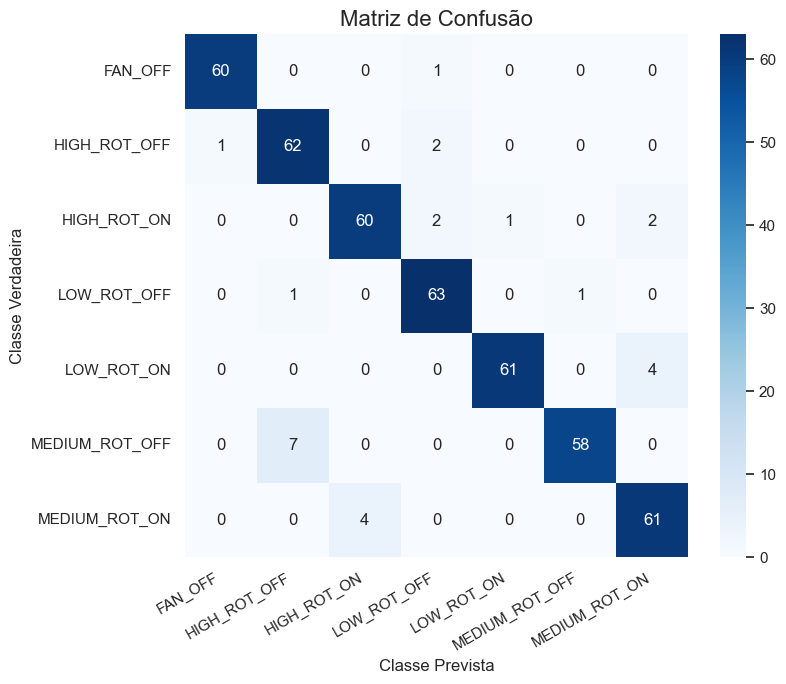

In [22]:
print("--- [5/9] Treinando e Avaliando o Modelo de Base ---")

if 'X_train' in locals():
    # Inicializa e treina o modelo
    gnb_model = GaussianNB()
    gnb_model.fit(X_train, y_train)

    # Avalia o modelo
    evaluate_model(gnb_model, X_test, y_test, label_encoder.classes_)
else:
    print("Conjunto de treino não definido.")

--- [6/9] Treinando e Avaliando o Modelo Random Forest ---
--- Avaliando Modelo: RandomForestClassifier ---
Acurácia no Teste: 97.56%

Relatório de Classificação:
                precision    recall  f1-score   support

       FAN_OFF       0.98      1.00      0.99        61
  HIGH_ROT_OFF       0.93      0.98      0.96        65
   HIGH_ROT_ON       0.97      1.00      0.98        65
   LOW_ROT_OFF       1.00      1.00      1.00        65
    LOW_ROT_ON       1.00      0.95      0.98        65
MEDIUM_ROT_OFF       1.00      0.92      0.96        65
 MEDIUM_ROT_ON       0.95      0.97      0.96        65

      accuracy                           0.98       451
     macro avg       0.98      0.98      0.98       451
  weighted avg       0.98      0.98      0.98       451



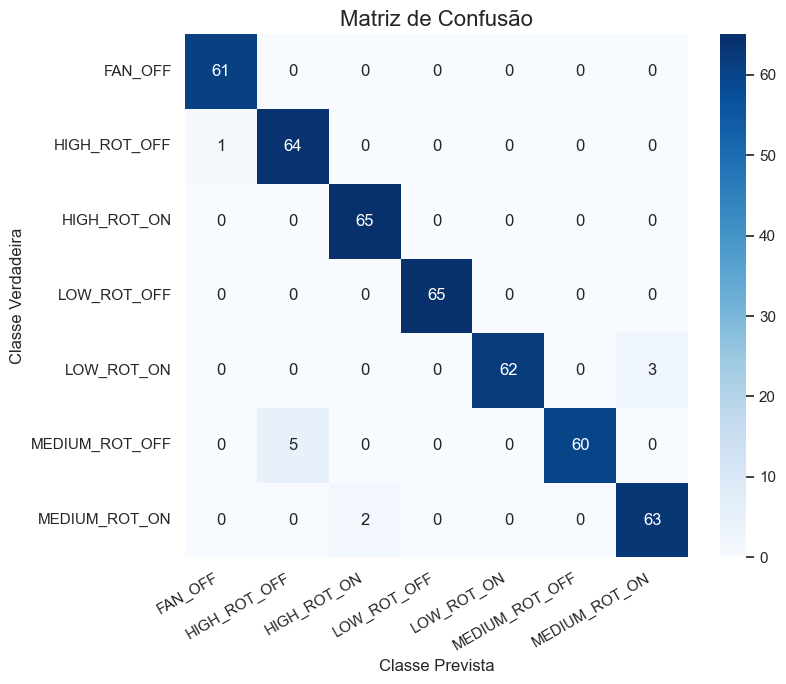

In [23]:
print("--- [6/9] Treinando e Avaliando o Modelo Random Forest ---")

if 'X_train' in locals():
    # Inicializa e treina o modelo
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    # Avalia o modelo
    evaluate_model(rf_model, X_test, y_test, label_encoder.classes_)
else:
    print("Conjunto de treino não definido.")

In [24]:
print("--- [6/9] Treinando e Avaliando o Modelo LightGBM ---")

if not HAS_LGBM:
    print("LightGBM nao disponivel. Pulando este modelo.")
elif 'X_train' in locals():
    # Inicializa e treina o modelo
    lgbm_model = lgb.LGBMClassifier(random_state=42)
    lgbm_model.fit(X_train, y_train)

    # Avalia o modelo
    evaluate_model(lgbm_model, X_test, y_test, label_encoder.classes_)
else:
    print("Conjunto de treino nao definido.")


--- [6/9] Treinando e Avaliando o Modelo LightGBM ---
LightGBM nao disponivel. Pulando este modelo.


--- [7/9] Comparando Modelos com Validacao Cruzada (Stratified + GroupKFold) ---

[GaussianNB] StratifiedKFold CV (n_splits=5)
  acc_mean=0.9370  acc_std=0.0089
  adjacent confusion rate=0.0554

[LogReg] StratifiedKFold CV (n_splits=5)
  acc_mean=0.9397  acc_std=0.0102
  adjacent confusion rate=0.0559

[RandomForest] StratifiedKFold CV (n_splits=5)
  acc_mean=0.9734  acc_std=0.0063
  adjacent confusion rate=0.0262


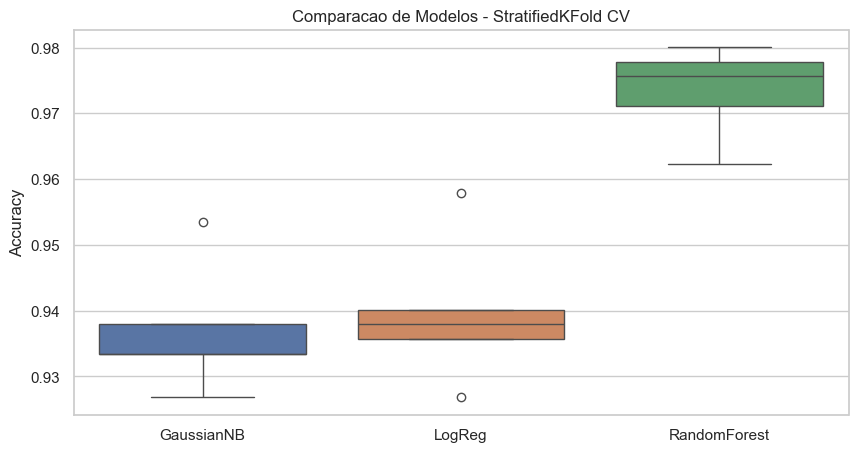

In [25]:
print("--- [7/9] Comparando Modelos com Validacao Cruzada (Stratified + GroupKFold) ---")

from sklearn.base import clone

def _cv_eval(model, X, y, *, labels_int, labels_names, cv, groups=None):
    fold_scores = []
    y_true_all = []
    y_pred_all = []

    X_df = X
    y_arr = np.asarray(y)
    g_arr = None
    if groups is not None:
        g_ser = groups.fillna('unknown') if hasattr(groups, 'fillna') else groups
        g_arr = np.asarray(g_ser)

    for train_idx, test_idx in cv.split(X_df, y_arr, g_arr):
        m = clone(model)
        m.fit(X_df.iloc[train_idx], y_arr[train_idx])
        pred = m.predict(X_df.iloc[test_idx])
        fold_scores.append(accuracy_score(y_arr[test_idx], pred))
        y_true_all.extend(y_arr[test_idx].tolist())
        y_pred_all.extend(np.asarray(pred).tolist())

    cm = confusion_matrix(y_true_all, y_pred_all, labels=labels_int)
    report = classification_report(
        y_true_all,
        y_pred_all,
        labels=labels_int,
        target_names=labels_names,
        output_dict=True,
        zero_division=0,
    )

    return {
        'fold_scores': [float(x) for x in fold_scores],
        'accuracy_mean': float(np.mean(fold_scores)) if fold_scores else None,
        'accuracy_std': float(np.std(fold_scores)) if fold_scores else None,
        'confusion_matrix': cm,
        'classification_report': report,
    }


def _adjacent_confusion_rate(cm, label_to_int, active_classes):
    """Calcula taxa de confusao entre classes adjacentes na ordem canonica.
    
    Para 3 classes: LOW<->MEDIUM confusions.
    Para 7 classes: confusoes entre vizinhos na ACTIVE_CLASSES order.
    """
    total = int(np.sum(cm)) if cm is not None else 0
    if total <= 0 or len(active_classes) < 2:
        return None
    confused = 0
    for i in range(len(active_classes) - 1):
        a = label_to_int.get(active_classes[i])
        b = label_to_int.get(active_classes[i + 1])
        if a is not None and b is not None:
            confused += cm[a, b] + cm[b, a]
    return float(confused / total)


if 'X' in locals() and 'y_encoded' in locals():
    labels_names = list(label_encoder.classes_)
    labels_int = list(range(len(labels_names)))
    label_to_int = {lbl: i for i, lbl in enumerate(labels_names)}

    # Ajustar n_splits para StratifiedKFold baseado no minimo de amostras por classe
    min_samples_per_class = min(pd.Series(y_encoded).value_counts().values)
    n_splits_strat = min(5, min_samples_per_class)
    if n_splits_strat < 2:
        n_splits_strat = 2
        print(f'[AVISO] Classe com apenas {min_samples_per_class} amostra(s). Usando n_splits={n_splits_strat}.')
    cv_strat = StratifiedKFold(n_splits=n_splits_strat, shuffle=True, random_state=42)

    # GroupKFold (por collection_id) - so roda se houver pelo menos 2 grupos
    cv_group = None
    n_groups = None
    if 'groups' in locals() and groups is not None:
        try:
            n_groups = int(pd.Series(groups).fillna('unknown').nunique())
        except Exception:
            n_groups = None
        if n_groups is not None and n_groups >= 2:
            cv_group = GroupKFold(n_splits=min(5, n_groups))

    models = {
        'GaussianNB': GaussianNB(),
        'LogReg': make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000),
        ),
        'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    }
    if HAS_LGBM:
        models['LightGBM'] = lgb.LGBMClassifier(random_state=42)

    CV_EVAL = {}
    results_strat = {}

    for name, model in models.items():
        print(f"\n[{name}] StratifiedKFold CV (n_splits={n_splits_strat})")
        strat = _cv_eval(
            model,
            X,
            y_encoded,
            labels_int=labels_int,
            labels_names=labels_names,
            cv=cv_strat,
            groups=None,
        )
        strat['adjacent_confusion_rate'] = _adjacent_confusion_rate(
            strat['confusion_matrix'], label_to_int, ACTIVE_CLASSES
        )
        CV_EVAL.setdefault(name, {})['stratified'] = strat
        results_strat[name] = strat['fold_scores']
        print(f"  acc_mean={strat['accuracy_mean']:.4f}  acc_std={strat['accuracy_std']:.4f}")
        if strat['adjacent_confusion_rate'] is not None:
            print(f"  adjacent confusion rate={strat['adjacent_confusion_rate']:.4f}")

        if cv_group is not None:
            print(f"[{name}] GroupKFold CV (groups={n_groups})")
            group = _cv_eval(
                model,
                X,
                y_encoded,
                labels_int=labels_int,
                labels_names=labels_names,
                cv=cv_group,
                groups=groups,
            )
            group['adjacent_confusion_rate'] = _adjacent_confusion_rate(
                group['confusion_matrix'], label_to_int, ACTIVE_CLASSES
            )
            CV_EVAL.setdefault(name, {})['groupkfold'] = group
            print(f"  acc_mean={group['accuracy_mean']:.4f}  acc_std={group['accuracy_std']:.4f}")
            if group['adjacent_confusion_rate'] is not None:
                print(f"  adjacent confusion rate={group['adjacent_confusion_rate']:.4f}")
        else:
            CV_EVAL.setdefault(name, {})['groupkfold'] = None

    # Exibir comparacao em grafico (StratifiedKFold)
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=pd.DataFrame(results_strat))
    plt.title('Comparacao de Modelos - StratifiedKFold CV')
    plt.ylabel('Accuracy')
    plt.show()
else:
    print("Conjunto de dados X/y_encoded nao definido.")

--- [8/9] Analisando a Importância das Features ---


C:\Users\Anderson\AppData\Local\Temp\ipykernel_27244\1920995887.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='viridis')


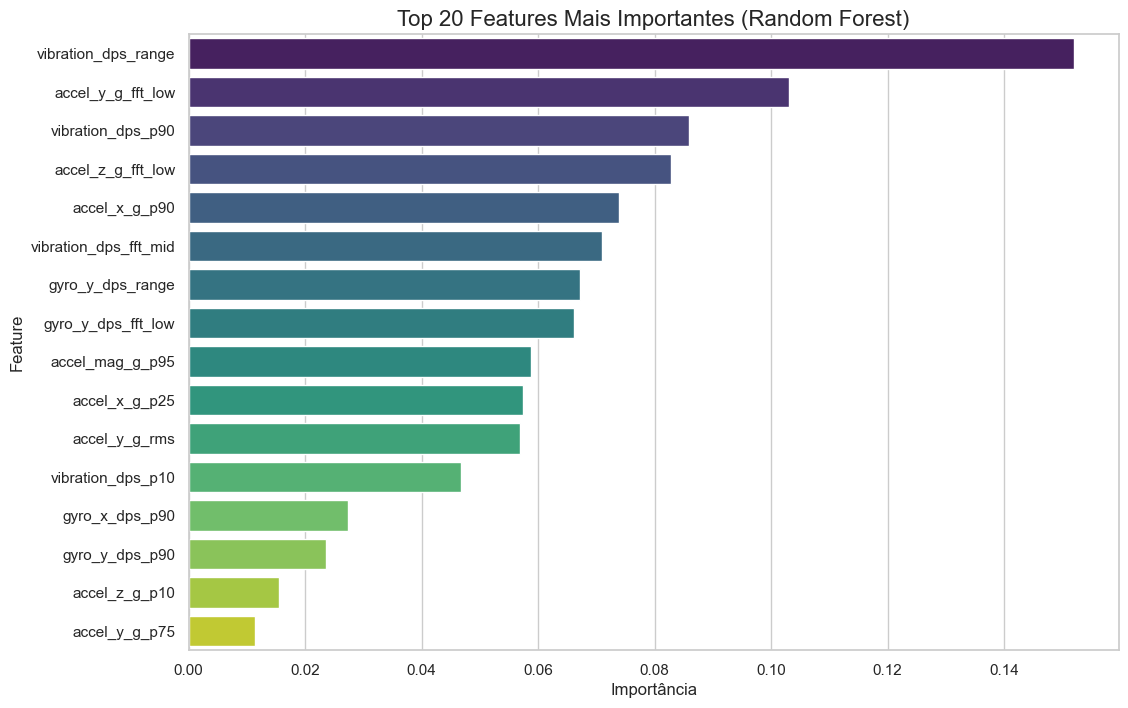

In [26]:
print("--- [8/9] Analisando a Importância das Features ---")

# Usaremos o modelo Random Forest, que já foi treinado, para esta análise
if 'rf_model' in locals():
    importances = rf_model.feature_importances_
    feature_names = X.columns
    
    # Cria um DataFrame para facilitar a ordenação e plotagem
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

    # Plota as 20 features mais importantes
    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='viridis')
    plt.title('Top 20 Features Mais Importantes (Random Forest)', fontsize=16)
    plt.xlabel('Importância', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.show()
else:
    print("Modelo Random Forest não foi treinado.")

In [27]:
print("--- [9/9] Treinando e Exportando o Modelo Final para o Dashboard ---")

from shared.traceability import hash_file, append_registry, load_json

FE_RUN_PATH = os.path.join(str(PATHS.output_metrics), 'feature_engineering_run.json')
fe_info = load_json(FE_RUN_PATH, default={})


# ---------------------------------------------------------------------------
# Helpers compartilhados para export de metricas / confusao
# ---------------------------------------------------------------------------

def _cm_to_dict_labels(cm, labels_names):
    cm = np.asarray(cm)
    return {
        labels_names[i]: {labels_names[j]: int(cm[i, j]) for j in range(len(labels_names))}
        for i in range(len(labels_names))
    }

def _jsonify_cv_block(block, labels_names):
    if not block:
        return None
    cm = block.get('confusion_matrix')
    cm_dict = _cm_to_dict_labels(cm, labels_names) if cm is not None else None
    return {
        'accuracy_mean': float(block.get('accuracy_mean')) if block.get('accuracy_mean') is not None else None,
        'accuracy_std':  float(block.get('accuracy_std'))  if block.get('accuracy_std')  is not None else None,
        'fold_scores': [float(x) for x in (block.get('fold_scores') or [])],
        'adjacent_confusion_rate': float(block.get('adjacent_confusion_rate')) if block.get('adjacent_confusion_rate') is not None else None,
        'confusion_matrix': cm_dict,
        'classification_report': block.get('classification_report'),
    }


def _build_eda_traceability(feature_config_info, fe_info, features_csv_file):
    fc = feature_config_info or {}
    fi = fe_info or {}
    fe_id = fi.get('fe_id') or fc.get('fe_id')
    features_csv_hash = fi.get('features_csv_hash') or fc.get('features_csv_hash')
    return {
        'feature_config_version': fc.get('version', '?'),
        'eda_id':         fc.get('eda_id', '?'),
        'fe_id':          fe_id or '?',
        'eda_generated_at': fc.get('generated_at', '?'),
        'sample_rate_hz': fc.get('sample_rate_hz', None),
        'selection_method': fc.get('selection_criteria', {}).get('method', '?'),
        'features_count': None,               # preenchido pelo caller
        'collection_ids': fc.get('collection_ids', []),
        'sampling_validation': fc.get('sampling_validation', {}),
        'features_csv_file': features_csv_file,
        'features_csv_hash': features_csv_hash,
    }


# ---------------------------------------------------------------------------
# export_gaussian_nb_model
# ---------------------------------------------------------------------------

def export_gaussian_nb_model(model, features, labels, output_path, feature_config_info=None, fe_info=None, features_csv_file=None, cv_eval=None):
    """Exporta GaussianNB para JSON compativel com classifier.js."""
    labels_names = list(labels)
    labels_int = list(range(len(labels_names)))
    train_acc = float(accuracy_score(y_encoded, model.predict(X)))

    # Holdout test
    test_metrics = None
    if 'X_test' in globals() and 'y_test' in globals():
        try:
            y_pred_test = model.predict(X_test)
            cm_test = confusion_matrix(y_test, y_pred_test, labels=labels_int)
            test_metrics = {
                'accuracy': float(accuracy_score(y_test, y_pred_test)),
                'confusion_matrix': _cm_to_dict_labels(cm_test, labels_names),
                'classification_report': classification_report(
                    y_test, y_pred_test, labels=labels_int,
                    target_names=labels_names, output_dict=True, zero_division=0,
                ),
            }
        except Exception:
            pass

    cv_metrics = None
    cv_accuracy_mean = None
    if cv_eval:
        cv_metrics = {
            'stratified': _jsonify_cv_block((cv_eval or {}).get('stratified'), labels_names),
            'groupkfold': _jsonify_cv_block((cv_eval or {}).get('groupkfold'), labels_names),
        }
        if cv_metrics.get('stratified') and cv_metrics['stratified'].get('accuracy_mean') is not None:
            cv_accuracy_mean = float(cv_metrics['stratified']['accuracy_mean'])

    eda = _build_eda_traceability(feature_config_info, fe_info, features_csv_file)
    eda['features_count'] = len(features)

    export_data = {
        "type": "gaussian_nb",
        "version": f"py_{time.strftime('%Y%m%d')}",
        "generated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "generated_by": "03_Model_Training_Evaluation.ipynb",
        "features": features,
        "labels": labels_names,
        "n_classes": len(labels_names),
        "priors": {},
        "stats": {},
        "metrics": {
            "train_accuracy": train_acc,
            "cv_accuracy_mean": cv_accuracy_mean,
            "cv": cv_metrics,
            "holdout_test": test_metrics,
        },
        "training_info": {
            "total_samples": int(len(X)),
            "window_size": WINDOW_SIZE,
            "step_size": STEP,
            "n_classes": len(labels_names),
            "classes": labels_names,
        },
        "eda_traceability": eda,
    }

    if hasattr(model, 'class_prior_'):
        priors = model.class_prior_
    else:
        priors = model.class_count_ / model.class_count_.sum()

    for i, label in enumerate(labels):
        export_data["priors"][label] = float(priors[i])

    class_counts = getattr(model, 'class_count_', None)
    for i, label in enumerate(labels):
        export_data["stats"][label] = {}
        for j, feature in enumerate(features):
            export_data["stats"][label][feature] = {
                "mean": float(model.theta_[i, j]),
                "var":  float(model.var_[i, j]),
                "count": int(class_counts[i]) if class_counts is not None else None,
            }

    with open(output_path, 'w') as f:
        json.dump(export_data, f, indent=2)
    print(f"Modelo GaussianNB exportado: {os.path.abspath(output_path)}")

    eda = export_data['eda_traceability']
    print(f"  EDA ID: {eda['eda_id']} | FE ID: {eda['fe_id']} | v{eda['feature_config_version']}")
    print(f"  Acuracia treino={train_acc:.4f}  CV-mean={cv_accuracy_mean}")
    return export_data


# ---------------------------------------------------------------------------
# export_logreg_model
# ---------------------------------------------------------------------------

def export_logreg_model(model_pipeline, features, labels, output_path, feature_config_info=None, fe_info=None, features_csv_file=None, cv_eval=None):
    """Exporta LogisticRegression + StandardScaler para JSON."""
    labels_names = list(labels)
    labels_int = list(range(len(labels_names)))

    scaler = model_pipeline.named_steps.get('standardscaler')
    lr = model_pipeline.named_steps.get('logisticregression')
    if scaler is None or lr is None:
        raise ValueError('Pipeline esperado: StandardScaler -> LogisticRegression')

    classes = list(lr.classes_)
    order = [classes.index(i) for i in labels_int]
    coef = lr.coef_[order]
    intercept = lr.intercept_[order]

    eda = _build_eda_traceability(feature_config_info, fe_info, features_csv_file)
    eda['features_count'] = len(features)

    export_data = {
        'type': 'softmax_logreg',
        'version': f"py_{time.strftime('%Y%m%d')}",
        'generated_at': time.strftime("%Y-%m-%d %H:%M:%S"),
        'generated_by': '03_Model_Training_Evaluation.ipynb',
        'features': features,
        'labels': labels_names,
        'n_classes': len(labels_names),
        'scaler': {
            'mean':  [float(x) for x in scaler.mean_.tolist()],
            'scale': [float(x) for x in scaler.scale_.tolist()],
        },
        'weights': {
            'coef':      [[float(x) for x in row] for row in coef.tolist()],
            'intercept': [float(x) for x in intercept.tolist()],
        },
        'metrics': {
            'train_accuracy': float(accuracy_score(y_encoded, model_pipeline.predict(X))),
            'cv': {
                'stratified': _jsonify_cv_block((cv_eval or {}).get('stratified'), labels_names) if cv_eval else None,
                'groupkfold': _jsonify_cv_block((cv_eval or {}).get('groupkfold'), labels_names) if cv_eval else None,
            },
        },
        'eda_traceability': eda,
    }

    with open(output_path, 'w') as f:
        json.dump(export_data, f, indent=2)
    print(f"Modelo LogisticRegression exportado: {os.path.abspath(output_path)}")
    return export_data


# ---------------------------------------------------------------------------
# export_random_forest_model
# ---------------------------------------------------------------------------

def _serialize_sk_tree(tree_obj):
    """Serializa a estrutura interna de um sklearn DecisionTree em arrays planos.

    Format (flat arrays, comprimento = n_nodes):
      feature       : indice da feature usada no split (-2 = folha)
      threshold     : valor de corte do split
      children_left : indice do filho esquerdo (-1 = folha)
      children_right: indice do filho direito  (-1 = folha)
      value         : votos por classe em cada no (forma original: [n_nodes, 1, n_classes])
    """
    import numpy as np
    tree_ = tree_obj.tree_
    return {
        'n_nodes':        int(tree_.node_count),
        'feature':        tree_.feature.tolist(),
        'threshold':      [round(float(v), 8) for v in tree_.threshold],
        'children_left':  tree_.children_left.tolist(),
        'children_right': tree_.children_right.tolist(),
        # shape: [n_nodes, n_outputs=1, n_classes] → [n_nodes, n_classes]
        'value': tree_.value[:, 0, :].astype(int).tolist(),
    }


def export_random_forest_model(model, features, labels, output_path, feature_config_info=None, fe_info=None, features_csv_file=None, cv_eval=None):
    """Exporta RandomForestClassifier para JSON com estrutura completa das arvores.

    Formato compativel com inferencia Python backend e potencialmente JS (arvore plana).

    Estrutura do arquivo:
      type: "random_forest"
      features, labels, n_classes
      n_estimators, max_features
      classes: ordem numerica interna (mapeamento label_encoder)
      feature_importance: [{feature, importance}]
      metrics: train_accuracy, cv, holdout_test
      eda_traceability: (rastreabilidade da FE)
      trees: lista de arvores serializadas (arrays planos)
    """
    labels_names = list(labels)
    labels_int   = list(range(len(labels_names)))

    train_acc = float(accuracy_score(y_encoded, model.predict(X)))

    # Holdout test
    test_metrics = None
    if 'X_test' in globals() and 'y_test' in globals():
        try:
            y_pred_test = model.predict(X_test)
            cm_test = confusion_matrix(y_test, y_pred_test, labels=labels_int)
            test_metrics = {
                'accuracy': float(accuracy_score(y_test, y_pred_test)),
                'confusion_matrix': _cm_to_dict_labels(cm_test, labels_names),
                'classification_report': classification_report(
                    y_test, y_pred_test, labels=labels_int,
                    target_names=labels_names, output_dict=True, zero_division=0,
                ),
            }
        except Exception:
            pass

    cv_metrics = None
    cv_accuracy_mean = None
    if cv_eval:
        cv_metrics = {
            'stratified': _jsonify_cv_block((cv_eval or {}).get('stratified'), labels_names),
            'groupkfold': _jsonify_cv_block((cv_eval or {}).get('groupkfold'), labels_names),
        }
        if cv_metrics.get('stratified') and cv_metrics['stratified'].get('accuracy_mean') is not None:
            cv_accuracy_mean = float(cv_metrics['stratified']['accuracy_mean'])

    # Feature importance
    feature_importance = [
        {'feature': f, 'importance': float(imp)}
        for f, imp in sorted(
            zip(features, model.feature_importances_),
            key=lambda x: -x[1]
        )
    ]

    eda = _build_eda_traceability(feature_config_info, fe_info, features_csv_file)
    eda['features_count'] = len(features)

    # Serializar todas as arvores
    print(f"  Serializando {model.n_estimators} arvores...")
    trees_serialized = [_serialize_sk_tree(est) for est in model.estimators_]

    # Contagem de nos (diagnostico)
    n_nodes_total = sum(t['n_nodes'] for t in trees_serialized)
    n_nodes_mean  = n_nodes_total / len(trees_serialized) if trees_serialized else 0
    print(f"  Arvores: {len(trees_serialized)} | Nos totais: {n_nodes_total} | Media por arvore: {n_nodes_mean:.0f}")

    export_data = {
        'type':            'random_forest',
        'version':         f"py_{time.strftime('%Y%m%d')}",
        'generated_at':    time.strftime("%Y-%m-%d %H:%M:%S"),
        'generated_by':    '03_Model_Training_Evaluation.ipynb',
        'features':        features,
        'labels':          labels_names,
        'n_classes':       len(labels_names),
        'n_estimators':    model.n_estimators,
        'max_features':    str(model.max_features),
        'feature_importance': feature_importance,
        'metrics': {
            'train_accuracy':   train_acc,
            'cv_accuracy_mean': cv_accuracy_mean,
            'cv':          cv_metrics,
            'holdout_test': test_metrics,
        },
        'training_info': {
            'total_samples': int(len(X)),
            'window_size':   WINDOW_SIZE,
            'step_size':     STEP,
            'n_classes':     len(labels_names),
            'classes':       labels_names,
            'n_nodes_total': n_nodes_total,
            'n_nodes_mean_per_tree': round(n_nodes_mean, 1),
        },
        'eda_traceability': eda,
        'trees': trees_serialized,
    }

    with open(output_path, 'w') as f:
        json.dump(export_data, f, separators=(',', ':'))   # compacto (sem espacos)

    size_mb = os.path.getsize(output_path) / (1024 * 1024)
    print(f"Modelo RandomForest exportado: {os.path.abspath(output_path)}  ({size_mb:.2f} MB)")
    print(f"  Acuracia treino={train_acc:.4f}  CV-mean={cv_accuracy_mean}")
    eda_out = export_data['eda_traceability']
    print(f"  EDA ID: {eda_out['eda_id']} | FE ID: {eda_out['fe_id']} | v{eda_out['feature_config_version']}")
    return export_data


# ===========================================================================
# Bloco principal de exportacao
# ===========================================================================

if 'X' in locals():
    # Carregar feature_config para rastreabilidade
    fc_info = None
    config_path = os.path.join(str(PATHS.config_dir), 'feature_config.json')
    if os.path.exists(config_path):
        with open(config_path, 'r') as f:
            fc_info = json.load(f)

    registry_path = os.path.join(str(PATHS.output_metrics), 'pipeline_registry.json')
    DATE_SUFFIX = time.strftime('%Y%m%d')

    # -----------------------------------------------------------------------
    # 1) GaussianNB
    # -----------------------------------------------------------------------
    print("\n[1/3] Treinando e exportando GaussianNB final...")
    final_gnb_model = GaussianNB()
    final_gnb_model.fit(X, y_encoded)

    gnb_filename = f"gnb_model_{DATE_SUFFIX}.json"
    gnb_filepath  = os.path.join(PATH_MODELS, gnb_filename)

    gnb_export = export_gaussian_nb_model(
        final_gnb_model, list(X.columns), label_encoder.classes_, gnb_filepath,
        feature_config_info=fc_info, fe_info=fe_info, features_csv_file=FEATURES_CSV_FILE,
        cv_eval=(CV_EVAL.get('GaussianNB') if 'CV_EVAL' in globals() else None),
    )
    gnb_hash = hash_file(gnb_filepath)
    append_registry(registry_path, {
        'type': 'model_training', 'timestamp': time.strftime('%Y%m%d_%H%M%S'),
        'model_filename': gnb_filename, 'model_hash': gnb_hash,
        'feature_config_version': gnb_export.get('eda_traceability', {}).get('feature_config_version'),
        'eda_id': gnb_export.get('eda_traceability', {}).get('eda_id'),
        'fe_id':  gnb_export.get('eda_traceability', {}).get('fe_id'),
        'features_csv_file': gnb_export.get('eda_traceability', {}).get('features_csv_file'),
        'features_csv_hash': gnb_export.get('eda_traceability', {}).get('features_csv_hash'),
        'train_accuracy':  gnb_export.get('metrics', {}).get('train_accuracy'),
        'cv_accuracy_mean': gnb_export.get('metrics', {}).get('cv_accuracy_mean'),
        'features_count':  gnb_export.get('eda_traceability', {}).get('features_count'),
        'n_classes': gnb_export.get('n_classes'),
    })

    # -----------------------------------------------------------------------
    # 2) LogisticRegression
    # -----------------------------------------------------------------------
    print("\n[2/3] Treinando e exportando LogisticRegression final...")
    try:
        final_logreg_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
        final_logreg_model.fit(X, y_encoded)
        lr_filename = f"logreg_model_{DATE_SUFFIX}.json"
        lr_filepath  = os.path.join(PATH_MODELS, lr_filename)
        lr_export = export_logreg_model(
            final_logreg_model, list(X.columns), label_encoder.classes_, lr_filepath,
            feature_config_info=fc_info, fe_info=fe_info, features_csv_file=FEATURES_CSV_FILE,
            cv_eval=(CV_EVAL.get('LogReg') if 'CV_EVAL' in globals() else None),
        )
        lr_hash = hash_file(lr_filepath)
        append_registry(registry_path, {
            'type': 'model_training', 'timestamp': time.strftime('%Y%m%d_%H%M%S'),
            'model_filename': lr_filename, 'model_hash': lr_hash,
            'feature_config_version': lr_export.get('eda_traceability', {}).get('feature_config_version'),
            'eda_id': lr_export.get('eda_traceability', {}).get('eda_id'),
            'fe_id':  lr_export.get('eda_traceability', {}).get('fe_id'),
            'features_csv_file': lr_export.get('eda_traceability', {}).get('features_csv_file'),
            'features_csv_hash': lr_export.get('eda_traceability', {}).get('features_csv_hash'),
            'train_accuracy': lr_export.get('metrics', {}).get('train_accuracy'),
            'features_count': lr_export.get('eda_traceability', {}).get('features_count'),
            'n_classes': lr_export.get('n_classes'),
        })
    except Exception as e:
        print(f"[AVISO] Falha ao exportar LogisticRegression: {e}")
        lr_filename = None
        lr_filepath = None

    # -----------------------------------------------------------------------
    # 3) RandomForest  *** MODELO PRIMARIO ***
    # -----------------------------------------------------------------------
    print("\n[3/3] Treinando e exportando RandomForest final (MODELO PRIMARIO)...")
    final_rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    final_rf_model.fit(X, y_encoded)

    rf_filename = f"rf_model_{DATE_SUFFIX}.json"
    rf_filepath  = os.path.join(PATH_MODELS, rf_filename)

    rf_export = export_random_forest_model(
        final_rf_model, list(X.columns), label_encoder.classes_, rf_filepath,
        feature_config_info=fc_info, fe_info=fe_info, features_csv_file=FEATURES_CSV_FILE,
        cv_eval=(CV_EVAL.get('RandomForest') if 'CV_EVAL' in globals() else None),
    )
    rf_hash = hash_file(rf_filepath)
    append_registry(registry_path, {
        'type': 'model_training', 'timestamp': time.strftime('%Y%m%d_%H%M%S'),
        'model_filename': rf_filename, 'model_hash': rf_hash,
        'model_type': 'random_forest',
        'is_primary': True,
        'feature_config_version': rf_export.get('eda_traceability', {}).get('feature_config_version'),
        'eda_id': rf_export.get('eda_traceability', {}).get('eda_id'),
        'fe_id':  rf_export.get('eda_traceability', {}).get('fe_id'),
        'features_csv_file': rf_export.get('eda_traceability', {}).get('features_csv_file'),
        'features_csv_hash': rf_export.get('eda_traceability', {}).get('features_csv_hash'),
        'train_accuracy':   rf_export.get('metrics', {}).get('train_accuracy'),
        'cv_accuracy_mean': rf_export.get('metrics', {}).get('cv_accuracy_mean'),
        'features_count':   rf_export.get('eda_traceability', {}).get('features_count'),
        'n_classes': rf_export.get('n_classes'),
        'n_estimators': rf_export.get('n_estimators'),
    })

    # Variavel de deploy (usada pela celula 14)
    # RF e o modelo primario; GNB e o fallback browser (classifier.js suporta GNB nativamente)
    output_filepath = rf_filepath
    output_filename = rf_filename
    output_filepath_gnb = gnb_filepath
    output_filename_gnb = gnb_filename

    print()
    print('=== RESUMO DE EXPORTACAO ===')
    print(f'  GNB:         {gnb_filename}')
    print(f'  LogReg:      {lr_filename}')
    print(f'  RandomForest: {rf_filename}  <-- PRIMARIO (backend/analise)')
    print()
    print('--- Proximos Passos ---')
    print("1. Modelos salvos em notebooks/output/models/.")
    print("2. O RandomForest (rf_model_*.json) e o modelo primario — use para inferencia Python.")
    print("3. O GaussianNB (gnb_model_*.json) e usado pelo classifier.js (browser) — deploy via celula 14.")

else:
    print("Dataset nao foi criado.")

--- [9/9] Treinando e Exportando o Modelo Final para o Dashboard ---

[1/3] Treinando e exportando GaussianNB final...
Modelo GaussianNB exportado: c:\Users\Anderson\Downloads\oracle_iot_esp32_MPU6050_project-main\notebooks\output\models\gnb_model_20260222.json
  EDA ID: eda_20260222_152508 | FE ID: fe_20260222_152508 | v5.16
  Acuracia treino=0.9370  CV-mean=0.937028824833703

[2/3] Treinando e exportando LogisticRegression final...
Modelo LogisticRegression exportado: c:\Users\Anderson\Downloads\oracle_iot_esp32_MPU6050_project-main\notebooks\output\models\logreg_model_20260222.json

[3/3] Treinando e exportando RandomForest final (MODELO PRIMARIO)...
  Serializando 200 arvores...
  Arvores: 200 | Nos totais: 29884 | Media por arvore: 149
Modelo RandomForest exportado: c:\Users\Anderson\Downloads\oracle_iot_esp32_MPU6050_project-main\notebooks\output\models\rf_model_20260222.json  (0.96 MB)
  Acuracia treino=1.0000  CV-mean=0.9733924611973392
  EDA ID: eda_20260222_152508 | FE ID: fe

In [28]:
# === DEPLOY AUTOMATICO DO MODELO NO DASHBOARD ===
# Copia os modelos treinados para a pasta do projeto e atualiza o dashboard.js.
#
# Estrategia de deploy:
#   - RandomForest (rf_model_*.json)  → copiado para models/ como modelo primario
#   - GaussianNB   (gnb_model_*.json) → copiado para models/ como modelo do browser
#   - dashboard.js MODEL_URL          → aponta para GNB (unico tipo suportado pelo classifier.js)
#
# Para usar RF no backend Python: carregue rf_model_*.json e implemente inferencia via arvore.

import re
import shutil

dest_dir = os.path.join('..', 'models')
os.makedirs(dest_dir, exist_ok=True)

# 1. Copiar RandomForest (modelo primario) para models/
if 'rf_filepath' in dir() and rf_filepath and os.path.exists(rf_filepath):
    rf_dest = os.path.join(dest_dir, rf_filename)
    shutil.copy2(rf_filepath, rf_dest)
    print(f"RandomForest copiado para: {os.path.abspath(rf_dest)}")
    rf_size_mb = os.path.getsize(rf_dest) / (1024 * 1024)
    print(f"  Tamanho: {rf_size_mb:.2f} MB")
else:
    print("[AVISO] rf_filepath nao encontrado — celula 13 foi executada?")

# 2. Copiar GaussianNB (modelo browser) para models/
if 'output_filepath_gnb' in dir() and output_filepath_gnb and os.path.exists(output_filepath_gnb):
    gnb_dest = os.path.join(dest_dir, output_filename_gnb)
    shutil.copy2(output_filepath_gnb, gnb_dest)
    print(f"GaussianNB  copiado para: {os.path.abspath(gnb_dest)}")
elif 'output_filepath' in dir() and output_filepath and os.path.exists(output_filepath) and 'gnb' in output_filepath:
    # fallback: output_filepath e o proprio GNB
    gnb_dest = os.path.join(dest_dir, output_filename)
    shutil.copy2(output_filepath, gnb_dest)
    print(f"GaussianNB  copiado para: {os.path.abspath(gnb_dest)}")
    output_filename_gnb = output_filename
else:
    print("[AVISO] gnb_filepath nao encontrado.")
    output_filename_gnb = None

# 3. Atualizar MODEL_URL no dashboard.js (aponta para GNB — suportado pelo classifier.js)
dashboard_js_path = os.path.join('..', 'web', 'js', 'dashboard.js')
if output_filename_gnb and os.path.exists(dashboard_js_path):
    with open(dashboard_js_path, 'r', encoding='utf-8') as f:
        content = f.read()

    new_model_url = f"models/{output_filename_gnb}"
    updated_content = re.sub(
        r"(MODEL_URL:\s*')[^']+(')",
        rf"\g<1>{new_model_url}\2",
        content
    )

    if updated_content != content:
        with open(dashboard_js_path, 'w', encoding='utf-8') as f:
            f.write(updated_content)
        print(f"dashboard.js atualizado: MODEL_URL = '{new_model_url}'")
    else:
        print("MODEL_URL no dashboard.js ja estava correto.")
elif not os.path.exists(dashboard_js_path):
    print(f"dashboard.js nao encontrado em: {os.path.abspath(dashboard_js_path)}")

print()
print("=== DEPLOY CONCLUIDO ===")
print(f"  Modelo browser  (classifier.js): models/{output_filename_gnb}")
if 'rf_filename' in dir() and rf_filename:
    print(f"  Modelo primario (Python backend): models/{rf_filename}")
print()
print("  → Recarregue o dashboard (Ctrl+Shift+R) para usar o novo modelo.")

RandomForest copiado para: c:\Users\Anderson\Downloads\oracle_iot_esp32_MPU6050_project-main\models\rf_model_20260222.json
  Tamanho: 0.96 MB
GaussianNB  copiado para: c:\Users\Anderson\Downloads\oracle_iot_esp32_MPU6050_project-main\models\gnb_model_20260222.json
dashboard.js atualizado: MODEL_URL = 'models/gnb_model_20260222.json'

=== DEPLOY CONCLUIDO ===
  Modelo browser  (classifier.js): models/gnb_model_20260222.json
  Modelo primario (Python backend): models/rf_model_20260222.json

  → Recarregue o dashboard (Ctrl+Shift+R) para usar o novo modelo.
